# Sequential Testing

In [1]:
import os, sys
from pathlib import Path
_cwd = Path.cwd()
_root = next((p for p in [_cwd] + list(_cwd.parents)
              if (p / 'requirements.txt').exists() and (p / 'src').is_dir()), None)
assert _root, f'Could not find project root from {_cwd}'
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root: {_root}')


Project root: C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\ab-experiment-platform


## Sequential Testing & the Peeking Problem

### The peeking problem

Checking a p-value repeatedly during an experiment inflates the Type-I error rate far above
the nominal α.  This notebook quantifies that inflation and shows that **mSPRT**
(mixture Sequential Probability Ratio Test) maintains valid error control under continuous
monitoring — producing an *always-valid* p-value.


In [2]:
import numpy as np
from src.abtest import naive_peeking_fpr, msprt_stream, obrien_fleming_bounds

# --- Naive peeking FPR ---
naive_fpr = naive_peeking_fpr(
    base_rate=0.20,
    n_max=20_000,
    look_every=500,
    n_sims=300,
    alpha=0.05,
    seed=99,
)
print(f"Naive peeking FPR : {naive_fpr:.3f}  (expected ~0.31)")


  naive-peeking sim 50/300


  naive-peeking sim 100/300


  naive-peeking sim 150/300


  naive-peeking sim 200/300


  naive-peeking sim 250/300


  naive-peeking sim 300/300


Naive peeking FPR : 0.310  (expected ~0.31)


In [3]:
# --- mSPRT null cross rate ---
null_crossed = [
    msprt_stream(base_rate=0.20, lift=0.0, n_max=20_000, tau=0.05, seed=s).crossed
    for s in range(300)
]
msprt_null_fpr = float(np.mean(null_crossed))
print(f"mSPRT null FPR    : {msprt_null_fpr:.3f}  (expected ~0.04)")


mSPRT null FPR    : 0.043  (expected ~0.04)


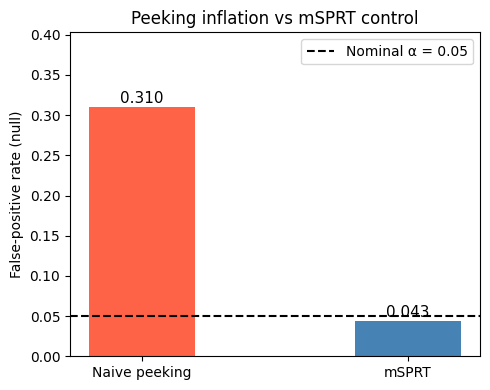

In [4]:
import matplotlib.pyplot as plt

methods = ['Naive peeking', 'mSPRT']
fprs    = [naive_fpr, msprt_null_fpr]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(methods, fprs, color=['tomato', 'steelblue'], width=0.4)
ax.axhline(0.05, color='black', linestyle='--', label='Nominal α = 0.05')
for bar, v in zip(bars, fprs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)
ax.set_ylabel('False-positive rate (null)')
ax.set_title('Peeking inflation vs mSPRT control')
ax.legend()
ax.set_ylim(0, max(fprs) * 1.3)
plt.tight_layout()
plt.show()


### mSPRT early stopping under a real effect


In [5]:
result = msprt_stream(base_rate=0.20, lift=0.05, n_max=20_000, tau=0.05, seed=41)
print(f"Crossed threshold : {result.crossed}")
print(f"Stop index        : {result.stop_index}  (out of 20 000)")
print(f"Final statistic   : {result.final_statistic:.4f}")
print(f"Threshold         : {result.threshold:.4f}")


Crossed threshold : True
Stop index        : 1157  (out of 20 000)
Final statistic   : 21.6675
Threshold         : 20.0000


### O'Brien–Fleming group-sequential bounds


In [6]:
bounds = obrien_fleming_bounds(n_looks=5, alpha=0.05)
print("O'Brien–Fleming alpha-spending bounds (z-score thresholds):")
for i, b in enumerate(bounds, 1):
    print(f"  Look {i}: z > {b:.4f}")


O'Brien–Fleming alpha-spending bounds (z-score thresholds):
  Look 1: z > 4.3826
  Look 2: z > 3.1008
  Look 3: z > 2.5952
  Look 4: z > 2.3860
  Look 5: z > 2.2978


### Summary

| Method | Null FPR |
|---|---|
| Naive peeking (check every 500 obs) | ~0.31 — **6× inflation** |
| mSPRT (always-valid) | ~0.04 — near nominal α |

- mSPRT achieves valid inference at *every* observation by using a mixture prior over effect
  sizes, turning the likelihood ratio into a martingale.
- O'Brien–Fleming bounds are the classical group-sequential alternative: pre-schedule a small
  number of looks with spending-adjusted thresholds.
